In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("solar_eolica_hidro_horario_2025.xls", index_col="datetime", parse_dates=["datetime"])
df

,solar_mw_real,eolica_mw_real,hidro_mw_real
datetime,,,
2025-01-01 01:00:00,0.0,49.2751,697.8249
2025-01-01 02:00:00,0.0,51.0014,700.4312
2025-01-01 03:00:00,0.0,52.9573,759.4326
2025-01-01 04:00:00,0.0,49.9941,741.1454
2025-01-01 05:00:00,0.0,44.1398,714.6162
...,...,...,...
2025-12-31 20:00:00,0.0,199.2321,724.3609
2025-12-31 21:00:00,0.0,179.4801,728.7116
2025-12-31 22:00:00,0.0,139.2375,735.9167


In [3]:
df2 = pd.read_csv("DEM2025.csv")
df2 = df2.rename(columns={"Unnamed: 0": "Date"})
df2["Date"] = pd.to_datetime(df2["Date"], errors="coerce")
df2 = df2.dropna(subset=["Date"])

df2 = df2.melt(id_vars="Date", var_name="Hour", value_name="Demand MW")
df2["datetime"] = df2["Date"] + pd.to_timedelta(df2["Hour"].str[1:].astype(int), unit="h")
demand = df2.set_index("datetime")[["Demand MW"]].sort_index()

In [4]:
merged = df.join(demand)
merged

,solar_mw_real,eolica_mw_real,hidro_mw_real,Demand MW
datetime,,,,
2025-01-01 01:00:00,0.0,49.2751,697.8249,1128.18
2025-01-01 02:00:00,0.0,51.0014,700.4312,1121.23
2025-01-01 03:00:00,0.0,52.9573,759.4326,1112.12
2025-01-01 04:00:00,0.0,49.9941,741.1454,1100.43
2025-01-01 05:00:00,0.0,44.1398,714.6162,1083.99
...,...,...,...,...
2025-12-31 20:00:00,0.0,199.2321,724.3609,1566.12
2025-12-31 21:00:00,0.0,179.4801,728.7116,1539.01
2025-12-31 22:00:00,0.0,139.2375,735.9167,1476.28


In [5]:
merged.rename ( {"solar_mw_real" : "Solar MW", 	"eolica_mw_real": "Wind MW", "hidro_mw_real": "Hydro MW"}, axis = 1, inplace = True)

In [6]:
merged

,Solar MW,Wind MW,Hydro MW,Demand MW
datetime,,,,
2025-01-01 01:00:00,0.0,49.2751,697.8249,1128.18
2025-01-01 02:00:00,0.0,51.0014,700.4312,1121.23
2025-01-01 03:00:00,0.0,52.9573,759.4326,1112.12
2025-01-01 04:00:00,0.0,49.9941,741.1454,1100.43
2025-01-01 05:00:00,0.0,44.1398,714.6162,1083.99
...,...,...,...,...
2025-12-31 20:00:00,0.0,199.2321,724.3609,1566.12
2025-12-31 21:00:00,0.0,179.4801,728.7116,1539.01
2025-12-31 22:00:00,0.0,139.2375,735.9167,1476.28


In [7]:
df = merged

In [8]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW
datetime,,,,
2025-01-01 01:00:00,0.0,49.2751,697.8249,1128.18
2025-01-01 02:00:00,0.0,51.0014,700.4312,1121.23
2025-01-01 03:00:00,0.0,52.9573,759.4326,1112.12
2025-01-01 04:00:00,0.0,49.9941,741.1454,1100.43
2025-01-01 05:00:00,0.0,44.1398,714.6162,1083.99
...,...,...,...,...
2025-12-31 20:00:00,0.0,199.2321,724.3609,1566.12
2025-12-31 21:00:00,0.0,179.4801,728.7116,1539.01
2025-12-31 22:00:00,0.0,139.2375,735.9167,1476.28


Text(0.5, 1.0, 'Hourly System Demand and Renewables Generation')

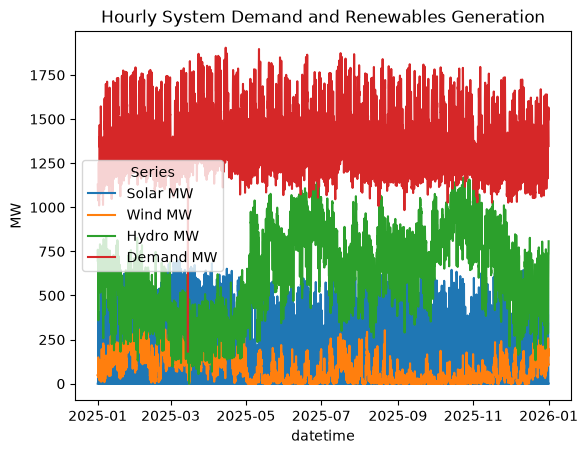

In [9]:
plot_df = df.reset_index().melt(id_vars="datetime", var_name="Series", value_name="MW")
sns.lineplot(data=plot_df, x="datetime", y="MW", hue="Series")

plt.ylabel("MW")
plt.title ("Hourly System Demand and Renewables Generation")

In [10]:
for k in df.index:

    if df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"] > df.loc[k, "Demand MW"]:
        df.loc[k, "Net load MW"] = 0
    else:
        df.loc[k, "Net load MW"] = df.loc[k, "Demand MW"] - (df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"])

In [11]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW,Net load MW
datetime,,,,,
2025-01-01 01:00:00,0.0,49.2751,697.8249,1128.18,381.0800
2025-01-01 02:00:00,0.0,51.0014,700.4312,1121.23,369.7974
2025-01-01 03:00:00,0.0,52.9573,759.4326,1112.12,299.7301
2025-01-01 04:00:00,0.0,49.9941,741.1454,1100.43,309.2905
2025-01-01 05:00:00,0.0,44.1398,714.6162,1083.99,325.2340
...,...,...,...,...,...
2025-12-31 20:00:00,0.0,199.2321,724.3609,1566.12,642.5270
2025-12-31 21:00:00,0.0,179.4801,728.7116,1539.01,630.8183
2025-12-31 22:00:00,0.0,139.2375,735.9167,1476.28,601.1258


Text(0.5, 1.0, 'Net Load')

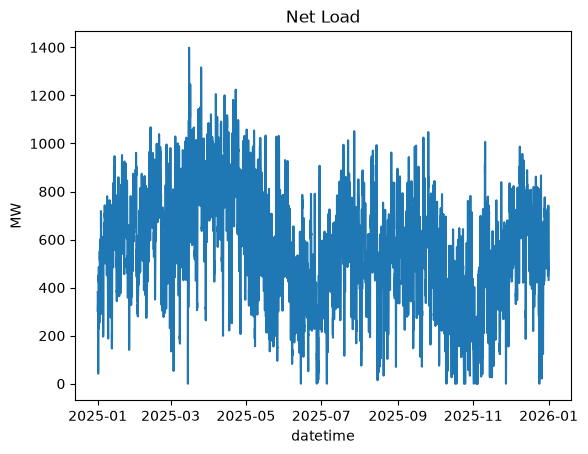

In [12]:
sns.lineplot(data=df.reset_index(), x="datetime", y="Net load MW")

plt.ylabel("MW")
plt.title ("Net Load")

Text(0.5, 1.0, 'Net Load')

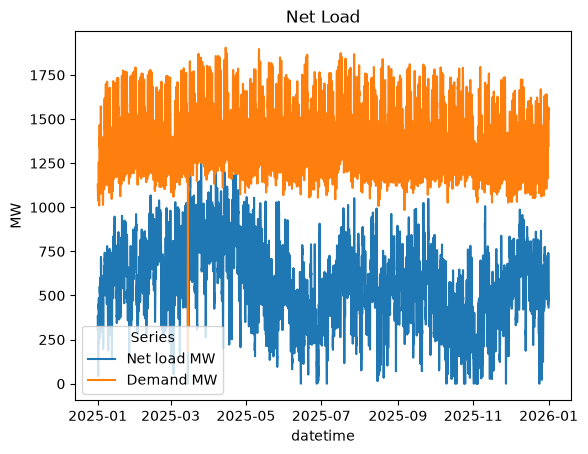

In [13]:
plot_df = df.reset_index().melt(id_vars="datetime", value_vars=["Net load MW", "Demand MW"], var_name="Series", value_name="MW")
sns.lineplot(data=plot_df, x="datetime", y="MW", hue="Series")

plt.ylabel("MW")
plt.title ("Net Load")

In [14]:
check = df[ "Net load MW"] > df[ "Demand MW"]
check

datetime
2025-01-01 01:00:00    False
2025-01-01 02:00:00    False
2025-01-01 03:00:00    False
2025-01-01 04:00:00    False
2025-01-01 05:00:00    False
                       ...  
2025-12-31 20:00:00    False
2025-12-31 21:00:00    False
2025-12-31 22:00:00    False
2025-12-31 23:00:00    False
2026-01-01 00:00:00    False
Length: 8760, dtype: bool

In [15]:
sum(check)


0

In [16]:
for k in df.index:

    if df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"] > df.loc[k, "Demand MW"]:
        df.loc[k, "Renewables Share %"] = 100
    else:
        df.loc[k, "Renewables Share %"] =  (df.loc[k, "Wind MW"] + df.loc[k, "Hydro MW"] + df.loc[k, "Solar MW"])/ df.loc[k, "Demand MW"]*100

In [17]:
df

,Solar MW,Wind MW,Hydro MW,Demand MW,Net load MW,Renewables Share %
datetime,,,,,,
2025-01-01 01:00:00,0.0,49.2751,697.8249,1128.18,381.0800,66.221702
2025-01-01 02:00:00,0.0,51.0014,700.4312,1121.23,369.7974,67.018596
2025-01-01 03:00:00,0.0,52.9573,759.4326,1112.12,299.7301,73.048763
2025-01-01 04:00:00,0.0,49.9941,741.1454,1100.43,309.2905,71.893669
2025-01-01 05:00:00,0.0,44.1398,714.6162,1083.99,325.2340,69.996587
...,...,...,...,...,...,...
2025-12-31 20:00:00,0.0,199.2321,724.3609,1566.12,642.5270,58.973323
2025-12-31 21:00:00,0.0,179.4801,728.7116,1539.01,630.8183,59.011423
2025-12-31 22:00:00,0.0,139.2375,735.9167,1476.28,601.1258,59.281044


Text(0.5, 1.0, ' Annual Renewable Contribuiton to Meet hourly Demand %')

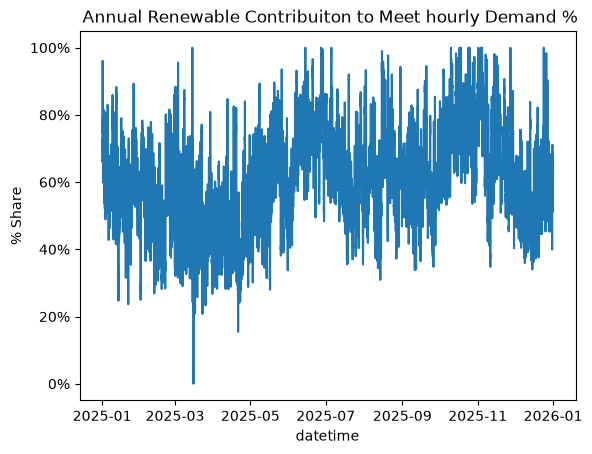

In [18]:
fig, ax = plt.subplots()
sns.lineplot(data=df.reset_index(), x="datetime", y="Renewables Share %", ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.ylabel("% Share")
plt.title(" Annual Renewable Contribuiton to Meet hourly Demand %")